# Parity oscillations

Here we simulate parity oscillations by preparing a cat state in the $x$ basis, and a global rotation around $I_x$. See https://www.nature.com/articles/s41567-024-02745-0 for more details on the cat states and Global rotations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.abspath('../'))
from src.spin import Spin

In [2]:
nucleus = Spin(I=7/2)
nucleus.make_xcat_state(phi=0)

pretty plotting, can make this a lot faster by choosing projection="hammer" for example

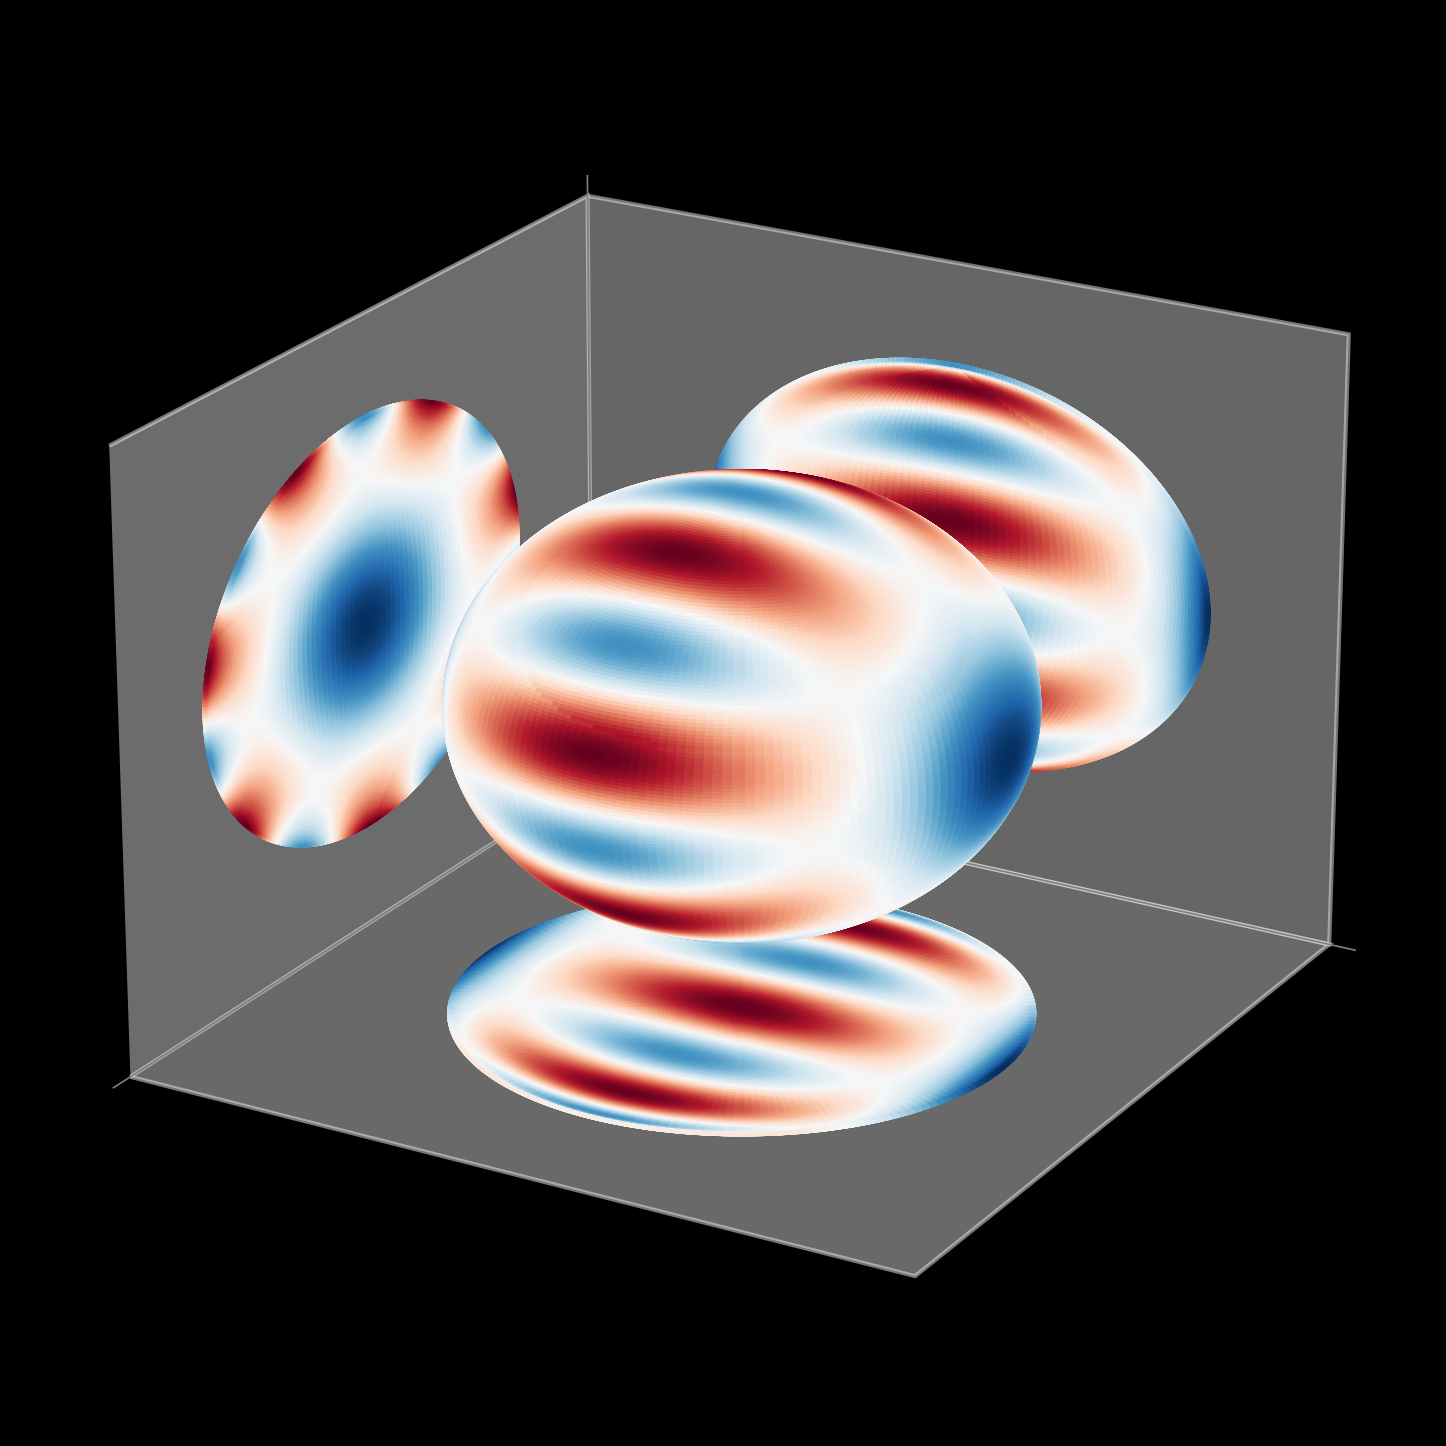

In [9]:
fig, ax, wigner, theta_mesh, phi_mesh = nucleus.plot_wigner(projection='3d_projection', figsize=(6,6))

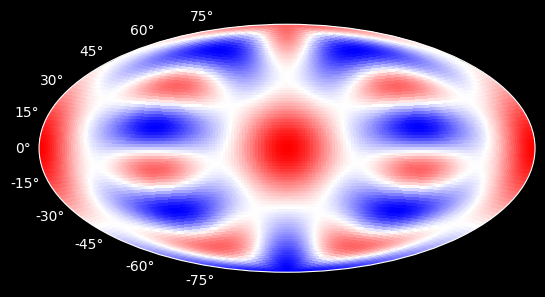

In [8]:
fig, ax = nucleus.plot_wigner(projection='hammer')

We can do a 'parity measurement' by calling the parity() function on the nucleus

In [3]:
nucleus.parity()

-0.9999999999999998

Parity oscillations by globally rotating around the $I_x$ axis

In [4]:
d_angle = np.pi/50
angles = np.arange(0, 2*np.pi + d_angle, d_angle)
states = np.zeros((len(angles), nucleus.dim), dtype=complex)
parities = np.zeros((len(angles)))
for i, angle in enumerate(angles):
    nucleus.global_rotate(d_angle, axis='x')
    states[i] = nucleus.state.full().flatten()
    parities[i] = nucleus.parity()

Text(0, 0.5, 'state')

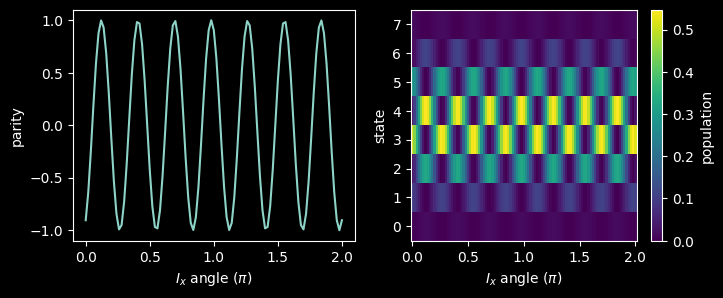

In [5]:
fig, ax = plt.subplots(1,2,figsize=(8,3))
ax[0].plot(angles/np.pi, parities)
ax[0].set_xlabel(r'$I_x$ angle ($\pi$)')
ax[0].set_ylabel(r'parity')

pcm = ax[1].pcolormesh(angles/np.pi, np.arange(8), np.abs(states.T)**2)
plt.colorbar(pcm, ax=ax[1], label='population')
ax[1].set_xlabel(r'$I_x$ angle ($\pi$)')
ax[1].set_ylabel(r'state')


make a gif of the state evolution during global rotation

In [6]:
from plotting.wigner_plot import make_wigner_gif

In [7]:
make_wigner_gif(states, r'gifs/parity_oscillations.gif', projection='hammer')

'gifs/parity_oscillations.gif'